# Simple Linear Regression


In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set default styles for our plots
sns.set_theme()

## 1. Data Preparation


In [22]:
X = np.array([1 , 3, 4, 6, 7]) # feature: years of experience
y = np.array([15,35,45,65,75]) # target: salary (in thousands)

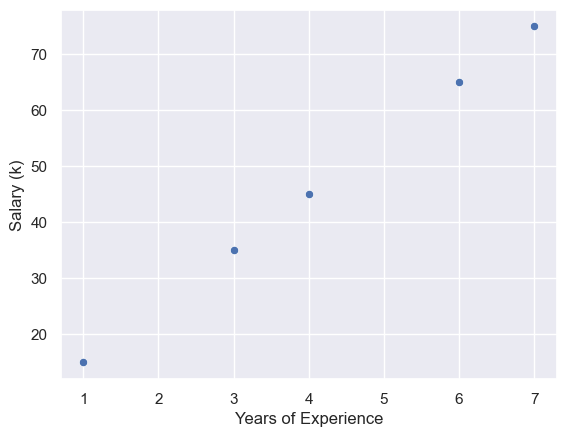

In [23]:
#relationship between experience and salary
sns.scatterplot(x=X, y=y)
plt.xlabel("Years of Experience")
plt.ylabel("Salary (k)")
plt.show()

## 2. Prediction Function
The linear model is defined as $f(x) = wx + b$. Here we create a function to generate predictions for our dataset.

In [24]:
def make_prediction(X, y, w, b):
  """Calculates the model output: f(x) = wx + b"""
  m = X.shape[0] # Number of training examples
  pred_list = np.zeros((m,)) # Initialize an array to store results

  for i in range(m):
    # Apply the linear regression formula
    pred_list[i] = w * X[i] + b

  return pred_list

Predictions (0,0): [0. 0. 0. 0. 0.]


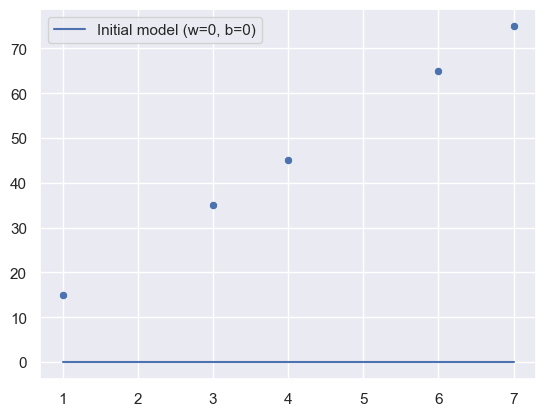

In [25]:
# test with w=0 and b=0
predictions = make_prediction(X, y, 0, 0)
print(f"Predictions (0,0): {predictions}")

#actual data vs initial predictions
sns.scatterplot(x=X, y=y)
plt.plot(X, predictions, label='Initial model (w=0, b=0)')
plt.legend()
plt.show()

[1. 3. 4. 6. 7.]


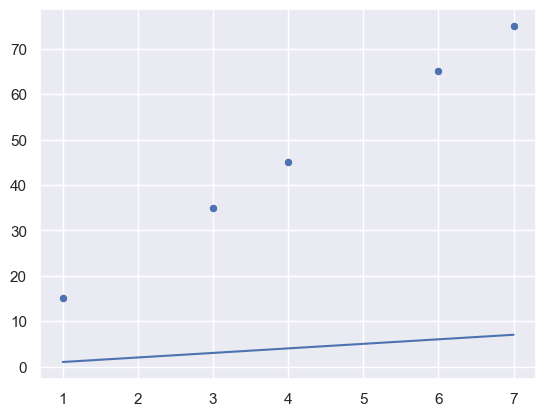

In [26]:
predictions = make_prediction(X,y,w=1,b=0)
print(predictions)

sns.scatterplot(x= X , y = y)
plt.plot(X ,predictions)

[ 8. 18. 23. 33. 38.]


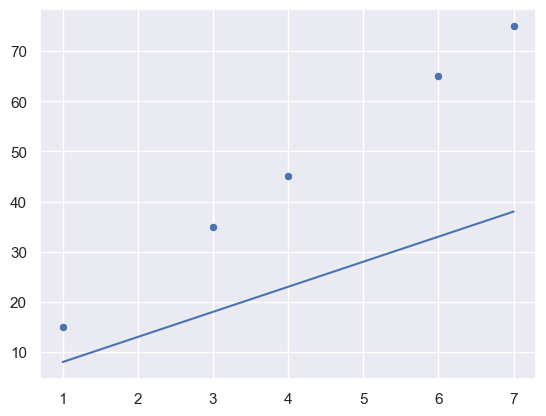

In [27]:
predictions = make_prediction(X,y,w=5,b=3)
print(predictions)

sns.scatterplot(x= X , y = y)
plt.plot(X ,predictions)

[15. 35. 45. 65. 75.]


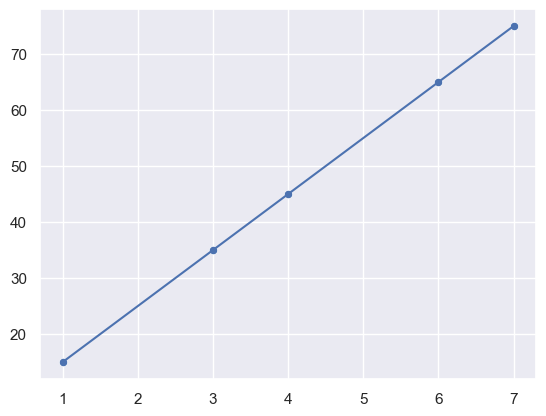

In [28]:
predictions = make_prediction(X,y,w=10,b=5)
print(predictions)

sns.scatterplot(x= X , y = y)
plt.plot(X ,predictions)

## 3. Cost Function
To evaluate how well our model fits, we calculate the 'Cost' (Mean Squared Error). A lower cost means a better fit.

In [29]:
def compute_cost(X, y, w, b):
  """Calculates the Mean Squared Error (MSE) to measure model accuracy"""
  m = X.shape[0]
  cost = 0.0

  for i in range(m):
    prediction = w * X[i] + b # i th feature value
    error = prediction - y[i] # Difference between prediction and actual value. i th target value
    error_squared = error ** 2
    cost = cost + error_squared

  # We divide by 2m for mathematical convenience in gradient calculations
  cost = cost / (2 * m)

  return cost

## 4. Visualizing the Cost
Let's see how the cost changes as we vary the weight $w$ while keeping $b$ constant. This produces a convex 'U-shaped' curve.

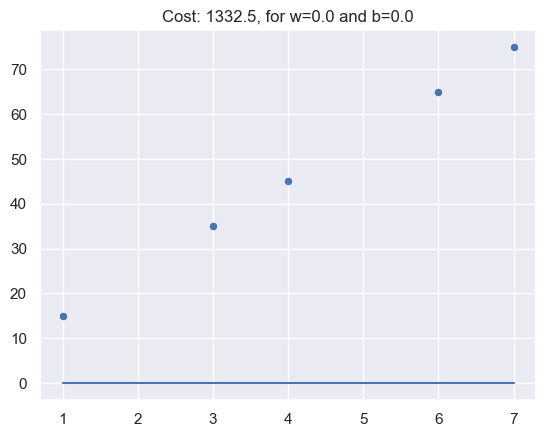

In [30]:
w = 0.0
b = 0.0

# Calculate predictions and evaluate cost manually
predictions = make_prediction(X, y, w=w, b=b)

sns.scatterplot(x=X, y=y)
plt.plot(X, predictions)
# The title shows the cost, helping us see how 'wrong' our line is
plt.title(f"Cost: {compute_cost(X, y, w=w, b=b)}, for w={w} and b={b}")
plt.show()

[1. 3. 4. 6. 7.]


Text(0.5, 1.0, 'Cost: 1100.6, for w =1.0 and b=0.0')

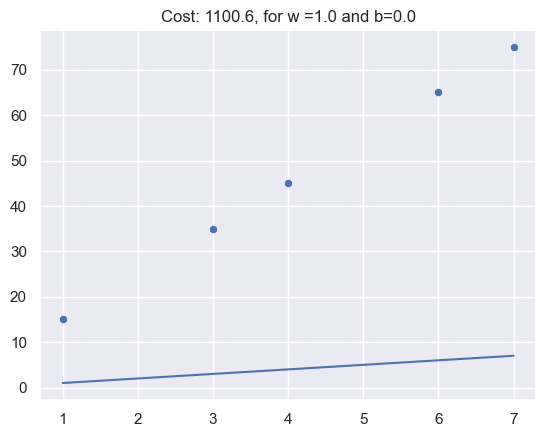

In [31]:
w= 1.0
b= 0.0

predictions = make_prediction(X,y,w=w,b=b)
print(predictions)

sns.scatterplot(x= X , y = y)
plt.plot(X ,predictions)

plt.title(f"Cost: {compute_cost(X,y,w=w,b=b)}, for w ={w} and b={b}")

[ 3.  7.  9. 13. 15.]


Text(0.5, 1.0, 'Cost: 852.8, for w =2.0 and b=1.0')

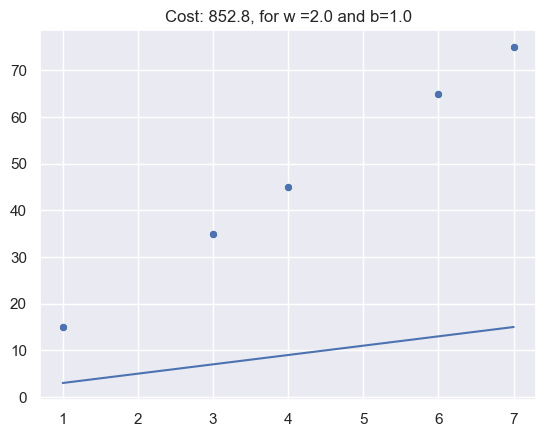

In [32]:
w= 2.0
b= 1.0

predictions = make_prediction(X,y,w=w,b=b)
print(predictions)

sns.scatterplot(x= X , y = y)
plt.plot(X ,predictions)

plt.title(f"Cost: {compute_cost(X,y,w=w,b=b)}, for w ={w} and b={b}")

[15. 35. 45. 65. 75.]


Text(0.5, 1.0, 'Cost: 0.0, for w =10.0 and b=5.0')

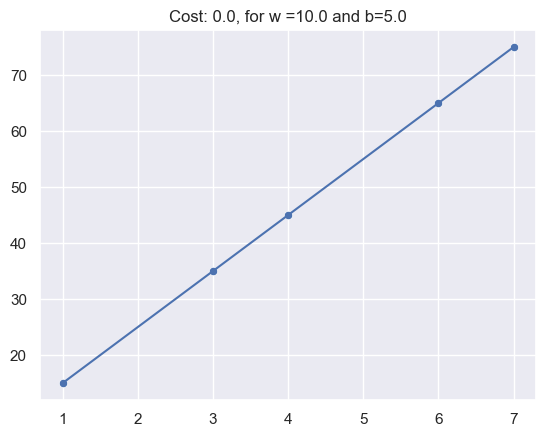

In [33]:
w= 10.0
b= 5.0

predictions = make_prediction(X,y,w=w,b=b)
print(predictions)

sns.scatterplot(x= X , y = y)
plt.plot(X ,predictions)

plt.title(f"Cost: {compute_cost(X,y,w=w,b=b)}, for w ={w} and b={b}")

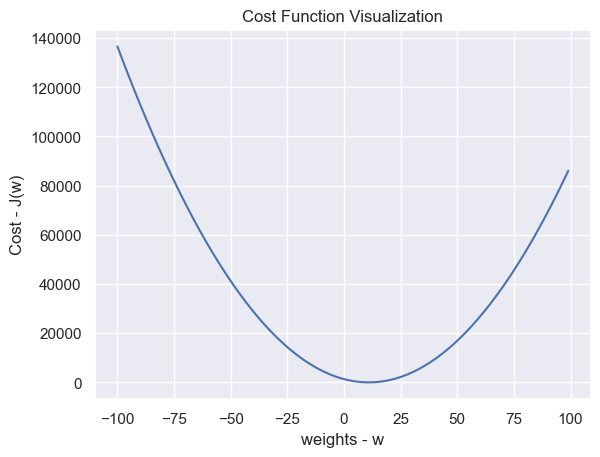

In [34]:
w_range = []
cost_history = []

# Loop through different weight values to see how they affect the cost
for i in range(-100, 100):
    cost_i = compute_cost(X, y, w=i, b=0)
    w_range.append(i)
    cost_history.append(cost_i)

# Plotting the Cost Function: The goal of ML is to find the bottom of this 'U'
plt.plot(w_range, cost_history)
plt.xlabel("weights - w")
plt.ylabel("Cost - J(w)")
plt.title("Cost Function Visualization")
plt.show()

h

## 5. Gradient Descent
Instead of guessing, we use the gradient (slope) to update $w$ and $b$ automatically until the cost is minimized.

In [35]:
def calculate_gradient(X, y, w, b):
  """Computes the gradient (direction to move) for w and b"""
  m = X.shape[0]
  dj_dw = 0.0 # Change needed for weight
  dj_db = 0.0 # Change needed for bias

  for i in range(m):
    prediction = w * X[i] + b
    error = prediction - y[i]
    # Multiply error by X[i] for the weight gradient
    dj_dw = dj_dw + (error * X[i])
    # The bias gradient is just the sum of errors
    dj_db = dj_db + error

  return dj_dw / m, dj_db / m

In [ ]:
def gradient_descent(X, y, w_input, b_input, max_iter, alpha=0.01):
  """Automates the tuning of w and b to minimize cost"""
  w = w_input
  b = b_input
  cost_memo = []
  iteration = []

  for i in range(max_iter):
    # 1. Calculate the gradients (the slope)
    dj_dw, dj_db = calculate_gradient(X, y, w, b)

    # 2. Update parameters by taking a small step (alpha) against the gradient
    w = w - alpha * dj_dw
    b = b - alpha * dj_db

    # 3. Track progress by saving the cost
    cost = compute_cost(X, y, w, b)
    cost_memo.append(cost)
    iteration.append(i)

    # Log the status every 100 steps
    if i % 100 == 0:
      print(f"Iteration {i}: Cost {cost:0.4f}, w: {w:0.4f}, b: {b:0.4f}")

  return w, b, cost_memo, iteration

### Run Gradient Descent
We initialize $w$ and $b$ at 0 and let the algorithm find the best values.

In [37]:
# Run gradient descent and store the results in w_final and b_final
w_final, b_final, cost_memo, iter_list = gradient_descent(X, y, w_input=0, b_input=0, max_iter=10000, alpha=0.01)

Iteration 0: Cost 790.3717, w: 2.4300, b: 0.4700
Iteration 100: Cost 0.6120, w: 10.4659, b: 2.5593
Iteration 200: Cost 0.4115, w: 10.3821, b: 2.9986
Iteration 300: Cost 0.2767, w: 10.3133, b: 3.3588
Iteration 400: Cost 0.1861, w: 10.2569, b: 3.6542
Iteration 500: Cost 0.1251, w: 10.2107, b: 3.8965
Iteration 600: Cost 0.0841, w: 10.1727, b: 4.0951
Iteration 700: Cost 0.0566, w: 10.1416, b: 4.2580
Iteration 800: Cost 0.0380, w: 10.1162, b: 4.3915
Iteration 900: Cost 0.0256, w: 10.0952, b: 4.5010
Iteration 1000: Cost 0.0172, w: 10.0781, b: 4.5909
Iteration 1100: Cost 0.0116, w: 10.0640, b: 4.6645
Iteration 1200: Cost 0.0078, w: 10.0525, b: 4.7249
Iteration 1300: Cost 0.0052, w: 10.0431, b: 4.7744
Iteration 1400: Cost 0.0035, w: 10.0353, b: 4.8150
Iteration 1500: Cost 0.0024, w: 10.0290, b: 4.8483
Iteration 1600: Cost 0.0016, w: 10.0237, b: 4.8756
Iteration 1700: Cost 0.0011, w: 10.0195, b: 4.8980
Iteration 1800: Cost 0.0007, w: 10.0160, b: 4.9164
Iteration 1900: Cost 0.0005, w: 10.0131, b

Have a look at the dj_dw and dj_db section. The values are decreasing and tending to zero over the iterations. That means , once the algorithm converges to it's minimum point of the function , it kinda stop updating the parameters ( w and b )

## 6. Final Results & Prediction
Now we can use our optimized parameters to predict the salary for someone with 2 years of experience.

Optimized w: 10.0000, b: 5.0000


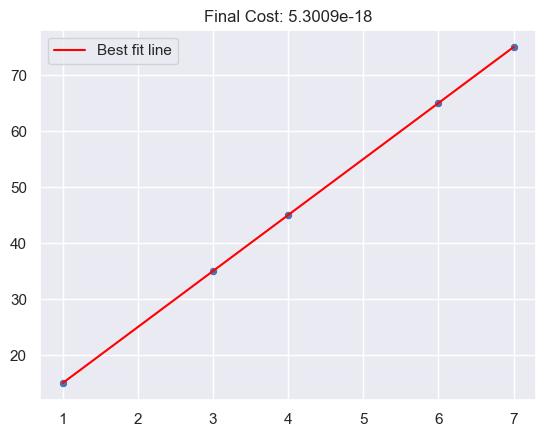

In [38]:
print(f"Optimized w: {w_final:0.4f}, b: {b_final:0.4f}")

# Get final predictions based on optimized parameters
final_preds = make_prediction(X, y, w=w_final, b=b_final)

# Visualize the final best-fit line
sns.scatterplot(x=X, y=y)
plt.plot(X, final_preds, color='red', label='Best fit line')
plt.title(f"Final Cost: {compute_cost(X, y, w_final, b_final):0.4e}")
plt.legend()
plt.show()

In [39]:
# Example: Predicting salary for someone with 2 years of experience
x_new = 2

# Using the formula f(x) = wx + b with our final calculated parameters
prediction = w_final * x_new + b_final
print(f"Predicted salary for {x_new} years of experience: {prediction:0.2f}k")

Predicted salary for 2 years of experience: 25.00k


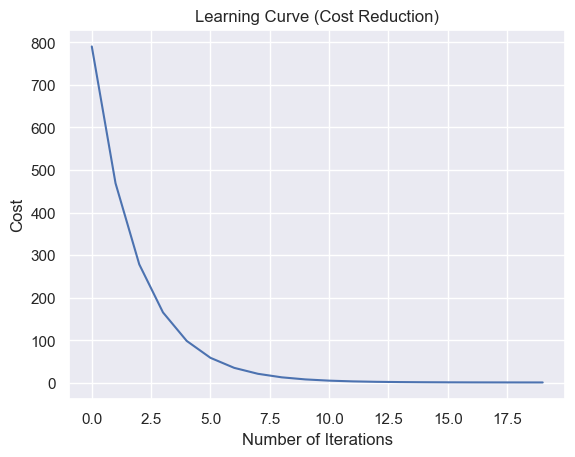

In [40]:
# Plot the cost over the first 20 iterations to see it dropping
plt.plot(iter_list[:20], cost_memo[:20])
plt.xlabel("Number of Iterations")
plt.ylabel("Cost")
plt.title("Learning Curve (Cost Reduction)")
plt.show()